### Agent Implementations: trained against random opponent

#### verS0 stands for S: small - size of board (4x5 board - 16 pieces), 0: no self-play - trained against random opponent
*Note: all configs, parameters and hyperparameters used in this phase are available in "../implementations/verS0_configs.txt", random vs random baseline is available in "random_vs_random_baseline.ipnyb"*

versions guide:

- N - 0 (cannot happen in current setup)
- X - {0: no, 1: yes}
- S0XYYNY, X - Is Double Net
- S0YXYNY, X - Is Dueling Net
- S0YYXNY, X - Is Residual Net
- S0YYYNX, X - Will do reward shaping

#### DQN vs DDQN

Log analysis:

| ver | label | eval max Q | eval min Q | avg Q (first eval) | avg Q (last eval) | max eval TD error | win% (best) | draw% (best) | **win% (end)** | draw% (end) | Beat baseline |
|---|---|---|---|---|---|---|---|---|----------------|---|---|
| S010000 | DDQN | 0.85 | 0.71 | -0.04 | 0.77 | 1.90 | 79.0% | 56.0% | **79.0%**      | 18.5% | Yes |
| S000000 | DQN | 12.13 | 10.69 | 11.49 | 3.84 | 23.35 | 26.5% | 79.9% | **17.5%**      | 75.0% | Yes |

Standard Deep Q Network due to instability with Q values and targets, and barely beating random opponent - will not be used as base for any further Grenight training. On the other side Double Deep Q Network had stable logs and I will use it as base in any other implementation.

#### DDQN vs DDQN + Additions

Log analysis:

| ver | label               | eval max Q | eval min Q | avg Q (first eval) | avg Q (last eval) | max eval TD error | eval win% (best) | **eval win% (end)** | eval draw% (end) | Beat baseline |
|---|---------------------|---|---|---|---|---|------------------|---------------------|------------------|---|
| S010100 | Residual DDQN       | 0.85 | 0.72 | 0.01 | 0.78 | 1.97 | 86.0%            | **86.0%**           | 10.0%            | Yes |
| S010000 | DDQN                | 0.85 | 0.71 | -0.04 | 0.77 | 1.90 | 79.0%            | **79.0%**           | 18.5%            | Yes |
| S010001 | Reward Shaping DDQN | 0.97 | 0.71 | -0.06 | 0.86 | 2.12 | 61.0%            | **57.0%**           | 41.5%            | Yes |
| S011000 | Dueling DDQN        | 1.01 | 0.63 | -0.06 | 0.78 | 2.03 | 59.5%            | **47.0%**           | 45.5%            | Yes |

Residual network architecture addition is the best addition and only one that actually is better than no addition when implementation is measured against intentional random opponent. But end goal is not beating random opponent, it is winning against player / Grenight implementation that is intelligent.

#### Implementations Tournament

To select initial self-play setup, next step is implementations tournament, to observe how implementations that are trained against random opponent are performing when opponent does not use random policy but trained one.

In [1]:
import matplotlib.pyplot as plt
from domain.configs import ROWS, COLUMNS
from environment.action_encoder import ActionEncoder
from environment.grenight_environment import GrenightEnvironment
from agent.grenight_agent import GrenightAgent
from agent.helpers.load_checkpoint import load_checkpoint
from agent.helpers.agents_duel import test_agents
from agent.helpers.renders import (build_decisive_win_matrix,
                                   build_overall_decisive_scores,
                                   build_same_impl_draw_scores,
                                   plot_heatmap,
                                   plot_ranking,
                                   plot_same_impl_draw_ranking,
                                   parse_games)

In [2]:
env_init = GrenightEnvironment(
    is_canonical_version=True, will_do_reward_shaping=False
)
env_init.action_encoder = ActionEncoder(is_canonical_version=False)

num_planes = env_init.state_encoder.num_planes
num_actions = env_init.action_encoder.num_actions

DoubleDQN = GrenightAgent(False, True, False, False, num_planes, ROWS, COLUMNS, num_actions)
load_checkpoint(DoubleDQN, "S010000", 10_000)

DuelingDDQN = GrenightAgent(False, True, True, False, num_planes, ROWS, COLUMNS, num_actions)
load_checkpoint(DuelingDDQN, "S011000", 10_000)

ResidualDDQN = GrenightAgent(False, True, False, True, num_planes, ROWS, COLUMNS, num_actions)
load_checkpoint(ResidualDDQN, "S010100", 10_000)

RewardShapingDDQN = GrenightAgent(False, True, False, False, num_planes, ROWS, COLUMNS, num_actions)
load_checkpoint(RewardShapingDDQN, "S010001", 10_000)

agents_dict = {
    "DoubleDQN": DoubleDQN,
    "ResidualDDQN": ResidualDDQN,
    "RewardShapingDDQN": RewardShapingDDQN,
    "DuelingDDQN": DuelingDDQN,
}

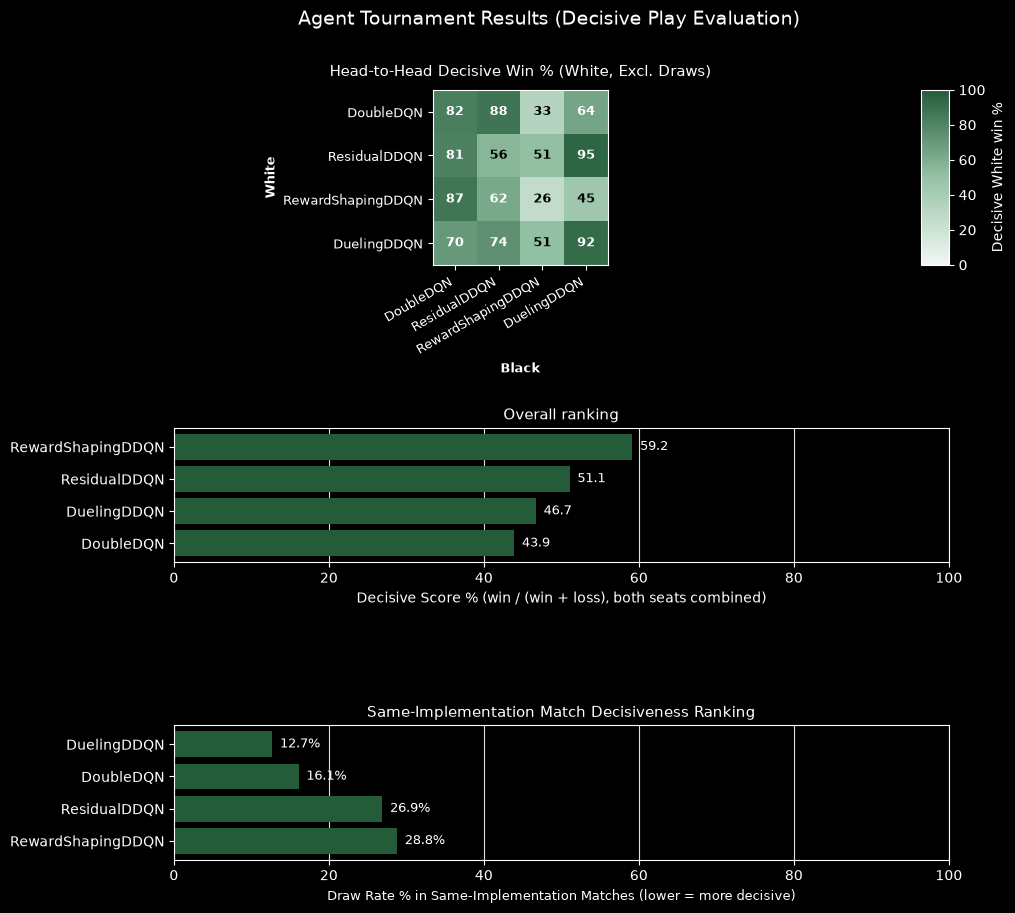

In [3]:
raw_logs = []
for white_name, white_agent in agents_dict.items():
    for black_name, black_agent in agents_dict.items():
        match_result = test_agents(
            white_agent, black_agent, white_name, black_name
        )
        raw_logs.append(match_result)

all_raw_logs = "\n".join(raw_logs)
games = parse_games(all_raw_logs)

matrix = build_decisive_win_matrix(games, agents_dict)
scores = build_overall_decisive_scores(games)
same_impl_scores = build_same_impl_draw_scores(games, agents_dict)

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.3, 1, 1],
    width_ratios=[1, 0.04],
    hspace=1.1,
    wspace=0.15
)

ax_main = fig.add_subplot(gs[0, 0])
ax_cbar = fig.add_subplot(gs[0, 1])
ax_rank = fig.add_subplot(gs[1, :])
ax_same_impl = fig.add_subplot(gs[2, :])

im1 = plot_heatmap(
    ax_main,
    matrix,
    "Head-to-Head Decisive Win % (White, Excl. Draws)",
    {k: k for k in agents_dict.keys()}
)

plot_ranking(
    ax_rank,
    scores,
    {k: k for k in agents_dict.keys()}
)

plot_same_impl_draw_ranking(
    ax_same_impl,
    same_impl_scores,
    {k: k for k in agents_dict.keys()}
)

fig.colorbar(im1, cax=ax_cbar, label="Decisive White win %")
fig.suptitle("Agent Tournament Results (Decisive Play Evaluation)", fontsize=14, y=0.96)

plt.show()

#### Conclusion

All four agents were trained exclusively as White against random, with the black reply folded into a single macro-step transition rather than the agent seeing its own value at a black-to-move state. Cross-play puts every agent in the black seat half the time, so these results are testing them partly outside their trained regime, and should be read as an early signal rather than a final verdict. With that in mind, vs-random performance was not a reliable predictor of cross-play performance. ResidualDDQN, the strongest agent against random, was outscored in cross-play by two implementations that had scored worse against random. RewardShapingDDQN showed the biggest swing, going from the weakest by vs-random log metrics to the best overall in cross-play, suggesting the "won't convert" tendency that looked like a weakness against a weak opponent may actually be useful stability against a real one. DuelingDDQN remained the most decisive implementation, with the lowest draw rate in same-implementation matches, even though it ranked lowest overall against other trained nets, so its value decomposition seems to be producing decisive play without yet translating into stronger play. None of this is disqualifying for any implementation, it mainly says vs-random results shouldn't be trusted as the final word on strength.